In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn import tree

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

In [3]:
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)

Training samples: (120, 4)
Test samples: (30, 4)


In [4]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [5]:
# Predictions
y_pred = clf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


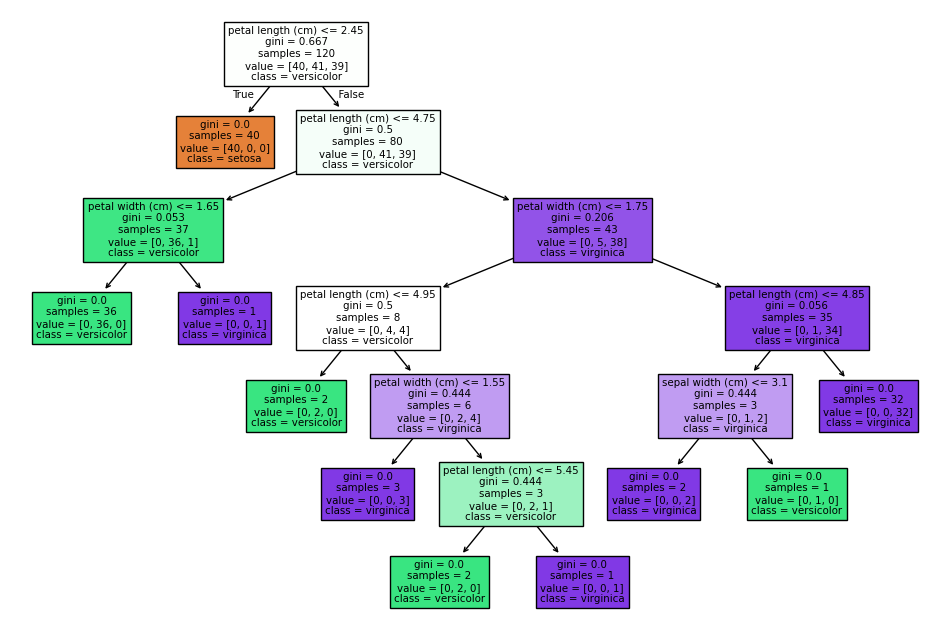

In [6]:
plt.figure(figsize=(12,8))
tree.plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.show()

In [7]:
# Gini (default)
clf_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
clf_gini.fit(X_train, y_train)

# Entropy
clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf_entropy.fit(X_train, y_train)

# Predictions
y_pred_gini = clf_gini.predict(X_test)
y_pred_entropy = clf_entropy.predict(X_test)

print("Gini Accuracy:", accuracy_score(y_test, y_pred_gini))
print("Entropy Accuracy:", accuracy_score(y_test, y_pred_entropy))

Gini Accuracy: 1.0
Entropy Accuracy: 1.0


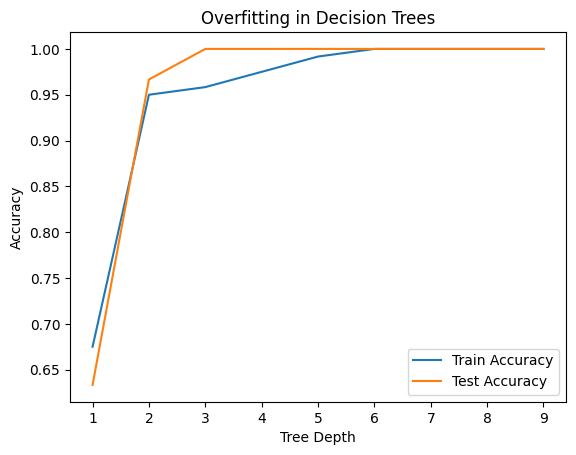

In [8]:
depths = range(1, 10)
train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

# Plot
plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Overfitting in Decision Trees")
plt.show()

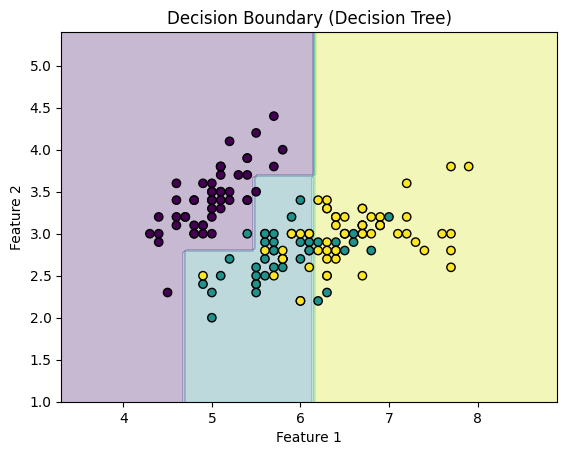

In [9]:
X_vis = X[:, :2]

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vis, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train_v, y_train_v)

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary (Decision Tree)")
plt.show()

In [10]:
deep_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
deep_tree.fit(X_train, y_train)

shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow_tree.fit(X_train, y_train)

print("Deep Tree Train Accuracy:", deep_tree.score(X_train, y_train))
print("Deep Tree Test Accuracy:", deep_tree.score(X_test, y_test))

print("Shallow Tree Train Accuracy:", shallow_tree.score(X_train, y_train))
print("Shallow Tree Test Accuracy:", shallow_tree.score(X_test, y_test))

Deep Tree Train Accuracy: 1.0
Deep Tree Test Accuracy: 1.0
Shallow Tree Train Accuracy: 0.9583333333333334
Shallow Tree Test Accuracy: 1.0


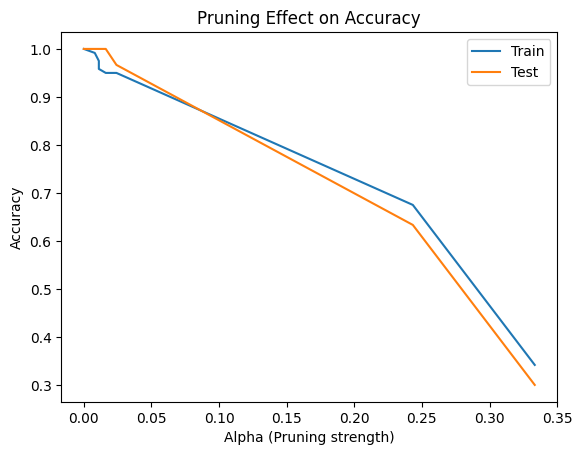

In [11]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

models = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    model.fit(X_train, y_train)
    models.append(model)

train_scores = [m.score(X_train, y_train) for m in models]
test_scores = [m.score(X_test, y_test) for m in models]

# Plot
plt.plot(ccp_alphas, train_scores, label="Train")
plt.plot(ccp_alphas, test_scores, label="Test")
plt.xlabel("Alpha (Pruning strength)")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Pruning Effect on Accuracy")
plt.show()

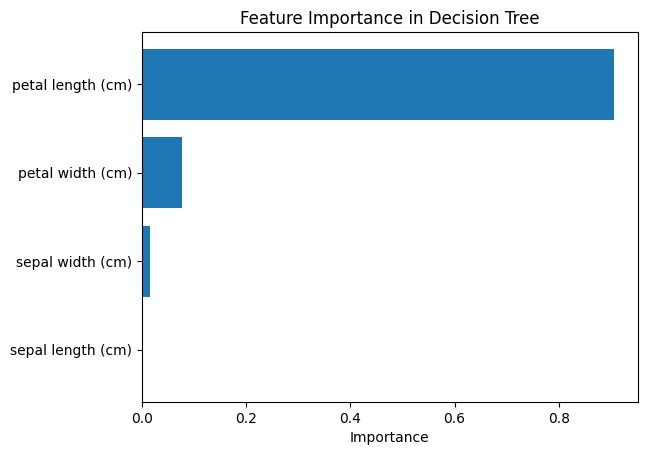

In [12]:
import pandas as pd

importances = clf.feature_importances_
features = iris.feature_names

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

feat_df = feat_df.sort_values(by='Importance', ascending=False)

plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance in Decision Tree")
plt.gca().invert_yaxis()
plt.show()

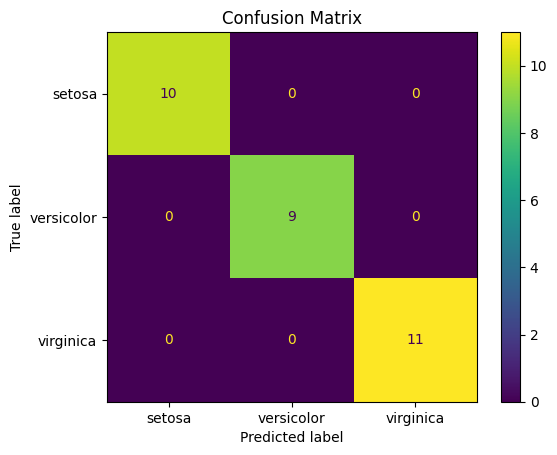

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=iris.target_names)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

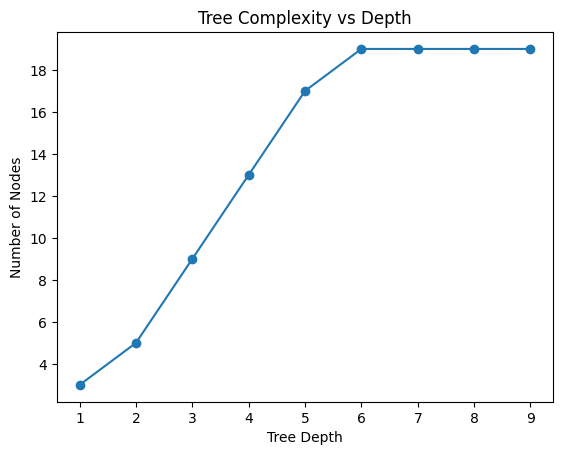

In [15]:
depths = range(1, 10)
nodes = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    nodes.append(model.tree_.node_count)

plt.plot(depths, nodes, marker='o')
plt.xlabel("Tree Depth")
plt.ylabel("Number of Nodes")
plt.title("Tree Complexity vs Depth")
plt.show()